In [47]:
# import typing and operator
from __future__ import annotations
import operator
from typing import List, Annotated, TypedDict, Optional
from pathlib import Path

# import llm, messages, OutputParser
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage
from pydantic import BaseModel, Field

# import langgraph orchastrator, and dotnev
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.6)

In [6]:
llm.invoke("what is Agent")

AIMessage(content='The term "agent" can have different meanings depending on the context. Here are a few possible definitions:\n\n1. **Intelligent Agent**: In artificial intelligence, an agent is a computer program that can perceive its environment, reason about it, and take actions to achieve a goal. Agents can be autonomous, meaning they operate independently, or they can be controlled by a human operator.\n2. **Software Agent**: A software agent is a program that performs a specific task, such as monitoring a system, gathering data, or executing a set of instructions. Examples of software agents include chatbots, virtual assistants, and malware.\n3. **Business Agent**: In business, an agent is a person or organization that acts on behalf of another person or organization. For example, a sales agent represents a company and sells its products or services, while a literary agent represents an author and negotiates book deals.\n4. **Government Agent**: In government, an agent is an emp

### Pydantic models

In [8]:
class Task(BaseModel):
    task_id: int
    title: str
    brief: str = Field(..., description="what to cover")

In [10]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [57]:
class BlogState(TypedDict):
    topic: str
    plan: Plan
    sections: Annotated[List[str], operator.add]
    final: Optional[str]

### Nodes

In [58]:
def orchastrator(state: BlogState):
    plan = llm.with_structured_output(Plan).invoke(
        [SystemMessage(content="create a blog plan with 5-7 sections on the following topic."),
         HumanMessage(content=f"Topic: {state['topic']}"),]
    )
    return {"plan": plan}

In [59]:
# special node, the fanout function is use when we don't know how many times we want to call a function in parallel.
def fanout(state: BlogState):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]

def worker(payload: dict) -> dict:
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = llm.invoke([
        SystemMessage(content="write one clean Markdown section."),
        HumanMessage(content=(
            f"Blog: {blog_title}\n"
            f"Topic: {topic}\n\n"
            f"Section: {task.title}\n"
            f"Brief: {task.brief}\n\n"
            f"Return only the section content in Markdown"
        ))
    ]).content.strip()

    return {"sections": [section_md]}

In [60]:
def reducer(state: BlogState):
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()
    
    final_md = f"# {title}\n\n{body}\n"

    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

### create graph

In [61]:
graph = StateGraph(BlogState)

graph.add_node("orchastrator", orchastrator)
graph.add_node("worker", worker)
graph.add_node("reducer", reducer)

In [62]:
graph.add_edge(START, "orchastrator")
graph.add_conditional_edges("orchastrator", fanout, ["worker"])
graph.add_edge("worker", "reducer")
graph.add_edge("reducer", END)

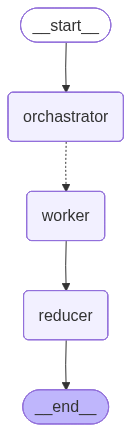

In [63]:
blog_writer_agent = graph.compile()
blog_writer_agent

In [64]:
output_blog = blog_writer_agent.invoke({
    "topic": "Write a blog on Self Attention"
})